## RPM 예측 모델

- Train1~4의 초반 2시간 데이터(1시간 단위 RPM 변화)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import glob, os
from nptdms import TdmsFile
from scipy.stats import kurtosis
from scipy.fft import fft, fftfreq
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import re

In [5]:
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    else:  # Linux (서버 환경)
        # 나눔 폰트 설치 후 사용
        # sudo apt-get install fonts-nanum
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                      capture_output=True)
        fm._load_fontmanager(try_read_cache=False)
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font_prop.get_name()

    plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

set_korean_font()

In [2]:
# !pip install xgboost

## 통계 피쳐 추가

### 진동 데이터 > 샤프트 주파수 방법

- 샤프트 주파수 방법 + 이진 분류 모델(750, 950)

In [14]:
FS          = 25600
WIN         = FS
TRAIN_PATH  = '../data/Train/'
TEST_PATH   = '../data/Test/'

FAULT_FREQ  = {'BPFI': 140, 'BPFO': 93, 'BSF': 78, 'Cage': 6.7}
FAULT_BW    = {'BPFI': 8,   'BPFO': 6,  'BSF': 6,  'Cage': 1.5}
CH_NAMES    = ['ch1', 'ch2', 'ch3', 'ch4']
RPM_MAP     = {0: 750.0, 1: 950.0}


# ============================================================
# Part 1. RPM 이진 분류 모델
# ============================================================

# ── 샤프트 주파수 피처 추출 (분류 모델 전용) ──────────────────
def extract_shaft_features(sig, fs=FS):
    N     = len(sig)
    freqs = fftfreq(N, 1/fs)[:N//2]
    mag   = np.abs(fft(sig))[:N//2]

    total_energy = np.sum(mag ** 2) + 1e-10
    shaft_mask   = (freqs >= 10.8) & (freqs <= 16.8)
    shaft_mag    = mag[shaft_mask]
    shaft_freq   = freqs[shaft_mask]

    peak_idx  = np.argmax(shaft_mag)
    peak_freq = shaft_freq[peak_idx]
    peak_mag  = shaft_mag[peak_idx]

    low_mask    = (freqs >= 10.8) & (freqs < 13.8)
    high_mask   = (freqs >= 13.8) & (freqs <= 16.8)
    low_energy  = np.sum(mag[low_mask]  ** 2)
    high_energy = np.sum(mag[high_mask] ** 2)
    confidence  = peak_mag / (shaft_mag.mean() + 1e-10)

    return {
        'peak_freq':          peak_freq,
        'peak_rpm':           peak_freq * 60,
        'peak_mag':           peak_mag,
        'confidence':         confidence,
        'low_energy':         low_energy,
        'high_energy':        high_energy,
        'energy_ratio':       low_energy / (high_energy + 1e-10),
        'shaft_energy_ratio': np.sum(shaft_mag ** 2) / total_energy,
    }


SHAFT_FEATS = [
    'peak_freq', 'peak_rpm', 'peak_mag', 'confidence',
    'low_energy', 'high_energy', 'energy_ratio', 'shaft_energy_ratio',
]


# ── 실측 RPM 로드 ─────────────────────────────────────────────
def load_rpm(train_num):
    path = os.path.join(TRAIN_PATH, f'Train{train_num}_Operation.csv')
    df   = pd.read_csv(path, encoding='cp949')
    df.columns = [c.strip() for c in df.columns]
    return df.set_index(df.columns[0])[df.columns[2]]


def epoch_rpm(rpm_series, f_num):
    t0  = (f_num - 1) * 600
    t1  = t0 + 60
    sub = rpm_series[(rpm_series.index >= t0) & (rpm_series.index <= t1)]
    return float(sub.mean()) if len(sub) > 0 else 850.0


# ── Train TDMS → 샤프트 피처 + rpm_label DataFrame ───────────
def build_shaft_df_for_training(train_num):
    vib_dir = os.path.join(TRAIN_PATH, f'Train{train_num}_Vibration')
    files   = sorted(
        [f for f in glob.glob(os.path.join(vib_dir, '*_labeled.tdms'))],
        key=lambda x: int(os.path.basename(x).split('_')[0])
    )
    rpm_series = load_rpm(train_num)
    rows = []

    for fpath in files:
        f_num      = int(os.path.basename(fpath).split('_')[0])
        rpm_actual = epoch_rpm(rpm_series, f_num)
        rpm_label  = 0 if rpm_actual < 825 else 1

        with TdmsFile.read(fpath) as tdms:
            ch1 = tdms.groups()[0].channels()[0][:].astype(np.float32)

        n_windows = len(ch1) // WIN
        for w in range(n_windows):
            sig  = ch1[w*WIN:(w+1)*WIN]
            feat = extract_shaft_features(sig)
            feat.update({'rpm_actual': rpm_actual, 'rpm_label': rpm_label})
            rows.append(feat)

    return pd.DataFrame(rows)


# ── RPM 이진 분류 모델 학습 (LOO 검증 포함) ───────────────────
def train_rpm_classifier():
    print('=== RPM 이진 분류 모델 학습 ===')

    shaft_dfs = {}
    for t in [1, 2, 3, 4]:
        shaft_dfs[t] = build_shaft_df_for_training(t)
        print(f'Train {t}: {len(shaft_dfs[t])}행')

    all_shaft = pd.concat(
        [df.assign(train=t) for t, df in shaft_dfs.items()],
        ignore_index=True
    )

    # LOO 검증
    print('\n=== Leave-One-Out 검증 ===')
    for test_t in [1, 2, 3, 4]:
        tr  = all_shaft[all_shaft['train'] != test_t]
        te  = all_shaft[all_shaft['train'] == test_t]
        mdl = XGBClassifier(n_estimators=200, max_depth=4,
                            learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, random_state=42,
                            verbosity=0)
        mdl.fit(tr[SHAFT_FEATS].values, tr['rpm_label'].values)
        pred = mdl.predict(te[SHAFT_FEATS].values)
        acc  = accuracy_score(te['rpm_label'].values, pred) * 100
        print(f'Test=Train{test_t} | 정확도={acc:.1f}%')
        print(classification_report(te['rpm_label'].values, pred,
                                    target_names=['저속(750)', '고속(950)']))

    # 최종 모델: 전체 데이터로 학습
    final_model = XGBClassifier(n_estimators=200, max_depth=4,
                                learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, random_state=42,
                                verbosity=0)
    final_model.fit(all_shaft[SHAFT_FEATS].values,
                    all_shaft['rpm_label'].values)
    print('\n최종 모델 학습 완료')
    return final_model


# ── 신호 → rpm_pred 예측 ─────────────────────────────────────
def predict_rpm(sig, model):
    feat = extract_shaft_features(sig)
    X    = np.array([[feat[f] for f in SHAFT_FEATS]])
    pred = model.predict(X)[0]
    return RPM_MAP[pred]


## 1초 단위 summary + feature enginnering

In [7]:
# ============================================================
# Part 2. TDMS → 1초 단위 요약 CSV 생성
# ============================================================

# ── 시간 도메인 피처 ──────────────────────────────────────────
def time_features(sig):
    rms      = np.sqrt(np.mean(sig ** 2))
    peak     = np.max(np.abs(sig))
    mean_abs = np.mean(np.abs(sig)) + 1e-10
    return {
        'max':            float(np.max(sig)),
        'min':            float(np.min(sig)),
        'mean':           float(np.mean(sig)),
        'median':         float(np.median(sig)),
        'rms':            rms,
        'kurtosis':       float(kurtosis(sig, fisher=True)),
        'peak2peak':      float(np.ptp(sig)),
        'crest_factor':   peak / (rms + 1e-10),
        'shape_factor':   rms / mean_abs,
        'impulse_factor': peak / mean_abs,
    }


# ── 주파수 도메인 피처 ────────────────────────────────────────
def freq_features(sig, rpm_pred):
    N     = len(sig)
    freqs = fftfreq(N, 1/FS)[:N//2]
    mag   = np.abs(fft(sig))[:N//2]
    power = mag ** 2
    total = np.sum(power) + 1e-10
    scale = rpm_pred / 1000

    result = {}

    result['spectral_centroid'] = float(np.sum(freqs * power) / total)

    np_norm = power / total
    np_norm = np_norm[np_norm > 0]
    result['spectral_entropy'] = float(-np.sum(np_norm * np.log2(np_norm)))

    for name, fc in FAULT_FREQ.items():
        bw   = FAULT_BW[name]
        band = (freqs >= fc * scale - bw) & (freqs <= fc * scale + bw)
        result[f'fault_{name}'] = float(
            np.sum(power[band]) / band.sum() if band.sum() > 0 else 0.0
        )

    return result


# ── TDMS → 1초 단위 요약 rows 생성 ───────────────────────────
def extract_summary_rows(tdms_path, f_num, rpm_model, is_test=False):
    with TdmsFile.read(tdms_path) as tdms:
        ch_data = {ch.name: ch[:].astype(np.float32)
                   for ch in tdms.groups()[0].channels()}

    signals   = [ch_data[f'CH{i+1}'] for i in range(4)]
    n_samples = len(signals[0])
    n_windows = n_samples // WIN  # 완전한 1초 구간만

    # Train: ttf/RUL 있음 / Test: 없음
    if not is_test:
        ttf     = float(ch_data['ttf'][0])
        rul_arr = ch_data['RUL']
    else:
        ttf     = None
        rul_arr = None

    rows = []
    for w in range(n_windows):
        start = w * WIN
        end   = start + WIN
        mid   = (start + end) // 2
        t_abs = (f_num - 1) * 600 + w + 0.5

        # CH1으로 rpm_pred 예측
        rpm_pred = predict_rpm(signals[0][start:end], rpm_model)

        row = {
            'epoch':    f_num,
            'window':   w,
            't_abs':    t_abs,
            'rpm_pred': rpm_pred,
        }

        # Train 전용 컬럼
        if not is_test:
            row['ttf']      = ttf
            row['RUL']      = float(rul_arr[mid])
            row['life_pct'] = t_abs / ttf * 100

        # 4채널 피처
        for i, sig_full in enumerate(signals):
            sig = sig_full[start:end]
            tag = CH_NAMES[i]
            for k, v in time_features(sig).items():
                row[f'{tag}_{k}'] = v
            for k, v in freq_features(sig, rpm_pred).items():
                row[f'{tag}_{k}'] = v

        rows.append(row)

    return rows


In [8]:
# ── Train 전체 → 요약 CSV ─────────────────────────────────────
def build_train_summary(train_num, rpm_model):
    vib_dir = os.path.join(TRAIN_PATH, f'Train{train_num}_Vibration')
    files   = sorted(
        [f for f in glob.glob(os.path.join(vib_dir, '*_labeled.tdms'))],
        key=lambda x: int(os.path.basename(x).split('_')[0])
    )

    all_rows = []
    for fpath in files:
        f_num = int(os.path.basename(fpath).split('_')[0])
        rows  = extract_summary_rows(fpath, f_num, rpm_model, is_test=False)
        all_rows.extend(rows)

    df        = pd.DataFrame(all_rows)
    save_path = os.path.join(
        TRAIN_PATH, f'Train{train_num}_Vibration_featured_summary.csv'
    )
    df.to_csv(save_path, index=False)
    print(f'Train {train_num}: {len(df)}행 | TTF={df["ttf"].iloc[0]:.0f}s '
          f'| 저장 → {save_path}')
    return df

# ── Test 전체 → 요약 CSV ──────────────────────────────────────
def build_test_summary(test_num, rpm_model):
    vib_dir = os.path.join(TEST_PATH, f'Test{test_num}_Vibration')
    files   = sorted(
        [f for f in glob.glob(os.path.join(vib_dir, '*.tdms'))],
        key=lambda x: int(os.path.basename(x).split('.')[0])
    )

    all_rows = []
    for fpath in files:
        f_num = int(os.path.basename(fpath).split('.')[0])
        rows  = extract_summary_rows(fpath, f_num, rpm_model, is_test=True)
        all_rows.extend(rows)

    df        = pd.DataFrame(all_rows)
    save_path = os.path.join(
        TEST_PATH, f'Test{test_num}_Vibration_featured_summary.csv'
    )
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)
    print(f'Test {test_num}: {len(df)}행 | 저장 → {save_path}')
    return df


In [15]:
## 실행

# Step 1. RPM 이진 분류 모델 학습
rpm_model = train_rpm_classifier()

# Step 2. Train 요약 CSV 생성
print('\n=== Train 요약 CSV 생성 ===')
train_dfs = {}
for t in [1, 2, 3, 4]:
    train_dfs[t] = build_train_summary(t, rpm_model)

# ── 피처 목록 확인 ────────────────────────────────────────────
print('\n=== 최종 피처 목록 ===')
meta_cols = ['epoch', 'window', 't_abs', 'rpm_pred',
             'ttf', 'RUL', 'life_pct']
feat_cols = [c for c in train_dfs[1].columns if c not in meta_cols]
print(f'총 {len(feat_cols)}개')
for c in feat_cols:
    print(f'  {c}')

=== RPM 이진 분류 모델 학습 ===
Train 1: 7560행
Train 2: 6840행
Train 3: 5340행
Train 4: 8220행

=== Leave-One-Out 검증 ===
Test=Train1 | 정확도=62.4%
              precision    recall  f1-score   support

     저속(750)       0.66      0.56      0.61      3900
     고속(950)       0.60      0.69      0.64      3660

    accuracy                           0.62      7560
   macro avg       0.63      0.63      0.62      7560
weighted avg       0.63      0.62      0.62      7560

Test=Train2 | 정확도=90.3%
              precision    recall  f1-score   support

     저속(750)       0.90      0.91      0.91      3540
     고속(950)       0.91      0.89      0.90      3300

    accuracy                           0.90      6840
   macro avg       0.90      0.90      0.90      6840
weighted avg       0.90      0.90      0.90      6840

Test=Train3 | 정확도=77.3%
              precision    recall  f1-score   support

     저속(750)       0.77      0.79      0.78      2760
     고속(950)       0.77      0.75      0.76      2580



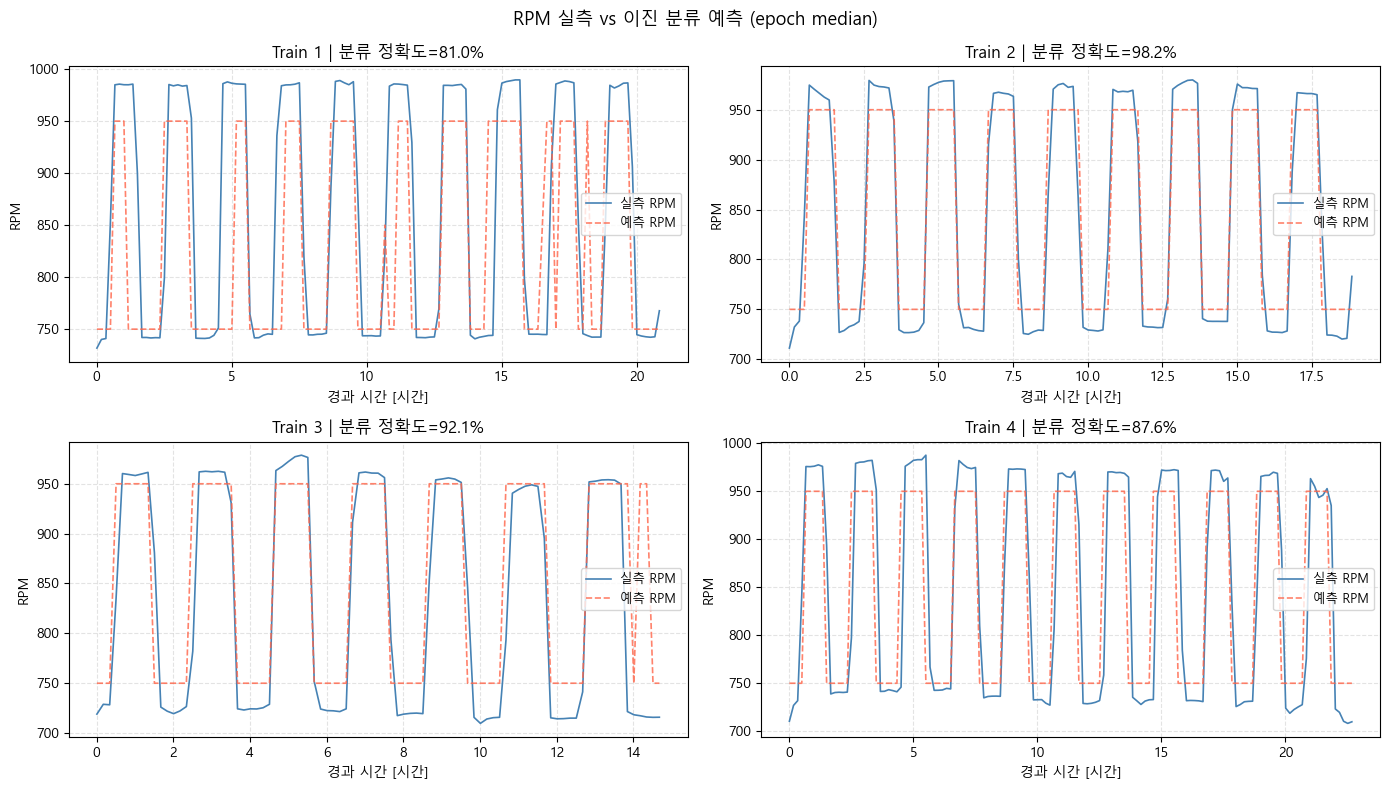

In [17]:
def plot_rpm_comparison():
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('RPM 실측 vs 이진 분류 예측 (epoch median)', fontsize=13)

    for idx, t in enumerate([1, 2, 3, 4]):
        ax = axes[idx // 2][idx % 2]

        # 실측 RPM (Operation CSV)
        rpm_series = load_rpm(t)
        rpm_actual = rpm_series.reset_index()
        rpm_actual.columns = ['t_abs', 'rpm_actual']

        # 예측 RPM (summary CSV)
        summary_path = os.path.join(
            TRAIN_PATH, f'Train{t}_Vibration_featured_summary.csv'
        )
        df_summary = pd.read_csv(summary_path)

        # epoch 단위 median 집계
        grp = df_summary.groupby('epoch').agg(
            t_abs   =('t_abs',    'median'),
            rpm_pred=('rpm_pred', 'median'),
        ).reset_index().sort_values('t_abs')

        # 실측 RPM을 t_abs 기준으로 매핑
        grp['rpm_actual'] = grp['t_abs'].apply(
            lambda t: rpm_series[
                (rpm_series.index >= t - 300) &
                (rpm_series.index <= t + 300)
            ].mean() if len(rpm_series[
                (rpm_series.index >= t - 300) &
                (rpm_series.index <= t + 300)
            ]) > 0 else 850.0
        )

        acc = (
            ((grp['rpm_actual'] > 825).astype(int) ==
             (grp['rpm_pred']   > 825).astype(int))
            .mean() * 100
        )

        ax.plot(grp['t_abs'] / 3600, grp['rpm_actual'],
                label='실측 RPM', linewidth=1.2, color='steelblue')
        ax.plot(grp['t_abs'] / 3600, grp['rpm_pred'],
                label='예측 RPM', linewidth=1.2,
                color='tomato', linestyle='--', alpha=0.8)

        ax.set_title(f'Train {t} | 분류 정확도={acc:.1f}%')
        ax.set_xlabel('경과 시간 [시간]')
        ax.set_ylabel('RPM')
        ax.legend(fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.35)

    plt.tight_layout()
    plt.savefig('./output/rpm_binary_comparison.png', bbox_inches='tight')
    plt.show()


# ── 실행 ─────────────────────────────────────────────────────

plot_rpm_comparison()

In [ ]:
def build_test_summary(test_num, rpm_model):
    # Test{num} 폴더 직접 접근
    vib_dir = os.path.join(TEST_PATH, f'Test{test_num}')
    files   = sorted(
        glob.glob(os.path.join(vib_dir, '*.tdms')),
        key=lambda x: int(os.path.basename(x).split('.')[0])
    )

    if len(files) == 0:
        print(f'Test {test_num}: 파일 없음 → 건너뜀')
        return None

    all_rows = []
    for fpath in files:
        f_num = int(os.path.basename(fpath).split('.')[0])
        rows  = extract_summary_rows(fpath, f_num, rpm_model, is_test=True)
        all_rows.extend(rows)

    df        = pd.DataFrame(all_rows)
    save_path = os.path.join(TEST_PATH, f'Test{test_num}_Vibration_featured_summary.csv')
    df.to_csv(save_path, index=False)
    print(f'Test {test_num}: {len(df)}행 | 저장 → {save_path}')
    return df


# Test 번호 자동 탐색
test_folders = glob.glob(os.path.join(TEST_PATH, 'Test*'))
test_nums    = sorted([
    int(re.search(r'Test(\d+)', os.path.basename(f)).group(1))
    for f in test_folders
    if os.path.isdir(f) and re.search(r'Test(\d+)', os.path.basename(f))
])

print(f'발견된 Test 번호: {test_nums}')

print('\n=== Test 요약 CSV 생성 ===')
test_dfs = {}
for t in test_nums:
    test_dfs[t] = build_test_summary(t, rpm_model)

발견된 Test 번호: [1, 2, 3, 4, 5, 6]

=== Test 요약 CSV 생성 ===
Test 1: 3000행 | 저장 → ../data/Test/Test1_Vibration_featured_summary.csv
Test 2: 3000행 | 저장 → ../data/Test/Test2_Vibration_featured_summary.csv
Test 3: 3000행 | 저장 → ../data/Test/Test3_Vibration_featured_summary.csv
Test 4: 3000행 | 저장 → ../data/Test/Test4_Vibration_featured_summary.csv
Test 5: 3000행 | 저장 → ../data/Test/Test5_Vibration_featured_summary.csv


- 베어링이 회전하면 샤프트도 같이 회전하는데 샤프트가 1초에 N번 회전하면 진동 신호에 Nhz 성분이 나타남         
ex. 750rpm = 1분에 750번 회전 = 1초에 12.5회전 > 진동 신호 FFT에서 12.5hz 피크가 발생

Train 1: 7560행 완료
Train 2: 6840행 완료
Train 3: 5340행 완료
Train 4: 8220행 완료

=== RPM 예측 성능 ===
Train 1 | MAE=110.0 RPM | 저속/고속 분류 정확도=62.1%
Train 2 | MAE=78.4 RPM | 저속/고속 분류 정확도=80.0%
Train 3 | MAE=81.6 RPM | 저속/고속 분류 정확도=77.3%
Train 4 | MAE=120.1 RPM | 저속/고속 분류 정확도=49.5%


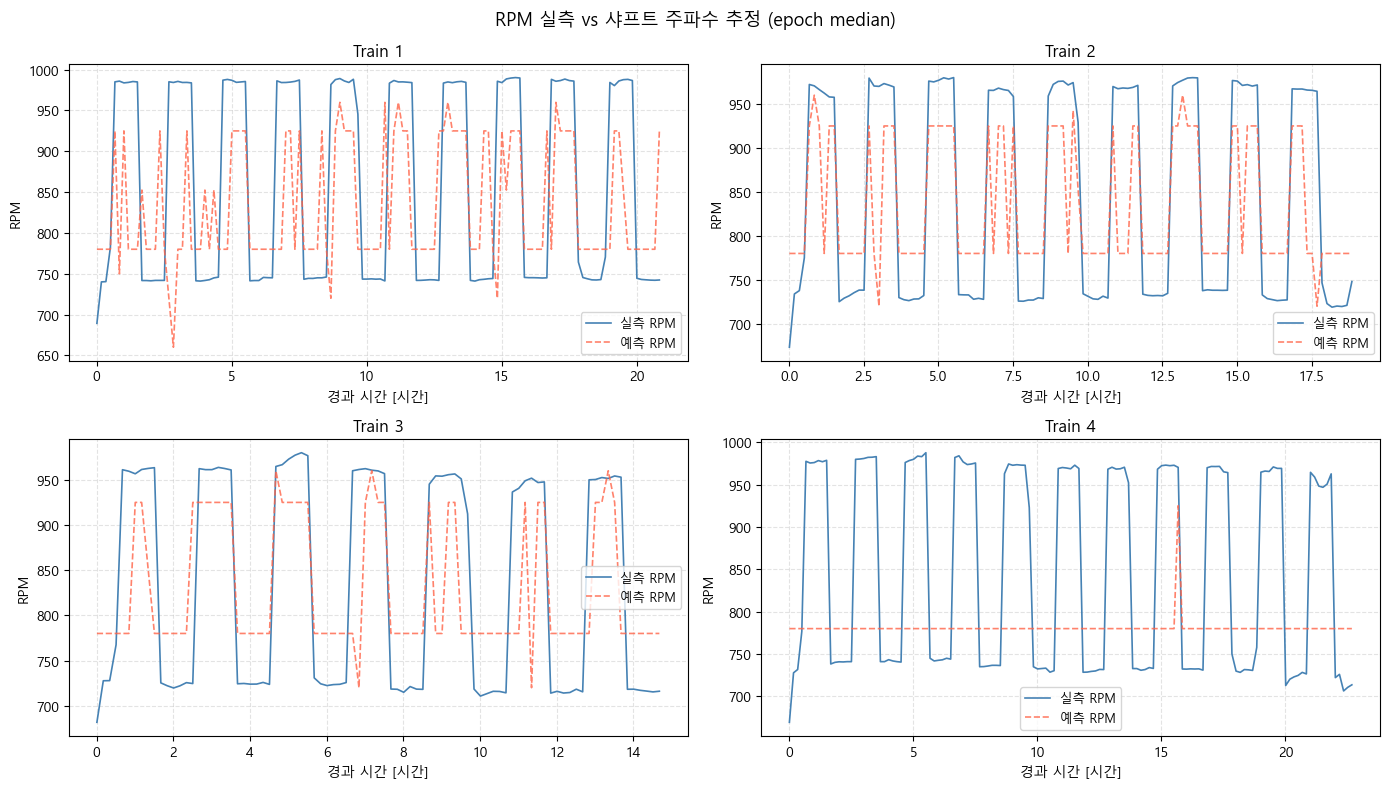

In [ ]:
# FS        = 25600
# WIN       = FS
# BASE_PATH = '../data/Train'


# # ──────────────────────────────────────────────
# # 샤프트 주파수 탐지 → RPM 추정
# # ──────────────────────────────────────────────
# def estimate_rpm_from_signal(sig, fs=FS):
#     """
#     진동 신호 FFT에서 샤프트 회전 주파수 피크 탐지
#     탐색 범위: 650~1010rpm → 10.8~16.8Hz
#     """
#     N     = len(sig)
#     freqs = fftfreq(N, 1/fs)[:N//2]
#     mag   = np.abs(fft(sig))[:N//2]

#     # 샤프트 주파수 탐색 범위
#     mask = (freqs >= 10.8) & (freqs <= 16.8)
#     if mask.sum() == 0:
#         return 850.0

#     peak_freq = freqs[mask][np.argmax(mag[mask])]
#     rpm_est   = peak_freq * 60

#     # 물리적 범위 클리핑 + 저속/고속 구간 보정
#     if rpm_est < 825:
#         return float(np.clip(rpm_est, 650, 800))
#     else:
#         return float(np.clip(rpm_est, 925, 1010))


# # ──────────────────────────────────────────────
# # RPM 로드 (실측)
# # ──────────────────────────────────────────────
# def load_rpm(train_num):
#     path = os.path.join(BASE_PATH, f'Train{train_num}_Operation.csv')
#     df   = pd.read_csv(path, encoding='cp949')
#     df.columns = [c.strip() for c in df.columns]
#     return df.set_index(df.columns[0])[df.columns[2]]


# def epoch_rpm(rpm_series, f_num):
#     t0  = (f_num - 1) * 600
#     t1  = t0 + 60
#     sub = rpm_series[(rpm_series.index >= t0) & (rpm_series.index <= t1)]
#     return float(sub.mean()) if len(sub) > 0 else 850.0


# # ──────────────────────────────────────────────
# # TDMS에서 1초 단위 rpm_pred 추출
# # ──────────────────────────────────────────────
# def extract_rpm_pred(train_num):
#     vib_dir = os.path.join(BASE_PATH, f'Train{train_num}_Vibration')
#     files   = sorted(
#         [f for f in glob.glob(os.path.join(vib_dir, '*_labeled.tdms'))],
#         key=lambda x: int(os.path.basename(x).split('_')[0])
#     )
#     rpm_series = load_rpm(train_num)

#     rows = []
#     for fpath in files:
#         f_num      = int(os.path.basename(fpath).split('_')[0])
#         rpm_actual = epoch_rpm(rpm_series, f_num)

#         with TdmsFile.read(fpath) as tdms:
#             ch1 = tdms.groups()[0].channels()[0][:].astype(np.float32)

#         n_windows = len(ch1) // WIN
#         for w in range(n_windows):
#             sig      = ch1[w*WIN:(w+1)*WIN]
#             rpm_pred = estimate_rpm_from_signal(sig)
#             t_abs    = (f_num - 1) * 600 + w + 0.5

#             rows.append({
#                 'epoch':      f_num,
#                 'window':     w,
#                 't_abs':      t_abs,
#                 'rpm_actual': rpm_actual,
#                 'rpm_pred':   rpm_pred,
#             })

#     df = pd.DataFrame(rows)
#     print(f'Train {train_num}: {len(df)}행 완료')
#     return df


# # ──────────────────────────────────────────────
# # 실행 및 비교
# # ──────────────────────────────────────────────
# rpm_dfs = {}
# for t in [1, 2, 3, 4]:
#     rpm_dfs[t] = extract_rpm_pred(t)

# # ── 성능 지표 ─────────────────────────────────
# print('\n=== RPM 예측 성능 ===')
# for t, df in rpm_dfs.items():
#     mae = (df['rpm_actual'] - df['rpm_pred']).abs().mean()

#     # 저속/고속 분류 정확도
#     df['actual_class'] = (df['rpm_actual'] > 825).astype(int)
#     df['pred_class']   = (df['rpm_pred']   > 825).astype(int)
#     acc = (df['actual_class'] == df['pred_class']).mean() * 100

#     print(f'Train {t} | MAE={mae:.1f} RPM | 저속/고속 분류 정확도={acc:.1f}%')

# # ── 트렌드 시각화 ─────────────────────────────
# fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# fig.suptitle('RPM 실측 vs 샤프트 주파수 추정 (epoch median)', fontsize=13)

# for idx, (t, df) in enumerate(rpm_dfs.items()):
#     ax  = axes[idx // 2][idx % 2]
#     grp = df.groupby('epoch').agg(
#         t_abs     =('t_abs',      'median'),
#         rpm_actual=('rpm_actual', 'median'),
#         rpm_pred  =('rpm_pred',   'median'),
#     ).sort_values('t_abs')

#     ax.plot(grp['t_abs'] / 3600, grp['rpm_actual'],
#             label='실측 RPM', linewidth=1.2, color='steelblue')
#     ax.plot(grp['t_abs'] / 3600, grp['rpm_pred'],
#             label='예측 RPM', linewidth=1.2,
#             color='tomato', linestyle='--', alpha=0.8)
#     ax.set_title(f'Train {t}')
#     ax.set_xlabel('경과 시간 [시간]')
#     ax.set_ylabel('RPM')
#     ax.legend(fontsize=9)
#     ax.grid(True, linestyle='--', alpha=0.35)

# plt.tight_layout()
# plt.savefig('./output/rpm_shaft_freq_validation.png', bbox_inches='tight')
# plt.show()

In [ ]:
# # 기존 featured CSV 로드 후 rpm_pred 병합해서 저장
# for t in [1, 2, 3, 4]:
#     # 기존 featured CSV 로드
#     featured_path = f'{BASE_PATH}/Train{t}_vibration_featured.csv'
#     df_feat = pd.read_csv(featured_path)

#     # rpm_pred 데이터 (epoch, window 기준으로 병합)
#     df_rpm = rpm_dfs[t][['epoch', 'window', 'rpm_pred']]

#     # 병합
#     df_feat = df_feat.merge(df_rpm, on=['epoch', 'window'], how='left')

#     # 저장
#     df_feat.to_csv(featured_path, index=False)
#     print(f'Train {t} 저장 완료 | shape={df_feat.shape} | '
#           f'rpm_pred 결측={df_feat["rpm_pred"].isna().sum()}개')

Train 1 저장 완료 | shape=(7560, 56) | rpm_pred 결측=0개
Train 2 저장 완료 | shape=(6840, 56) | rpm_pred 결측=0개
Train 3 저장 완료 | shape=(5340, 56) | rpm_pred 결측=0개
Train 4 저장 완료 | shape=(8220, 56) | rpm_pred 결측=0개
